In [1]:
import jaxshearlab as jsl
import dorito
import matplotlib.pyplot as plt
import jax.numpy as np
import matplotlib as mpl
from scipy.datasets import ascent

2025-04-15 17:11:48.023710: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [22]:
array = np.array(ascent())
source_size = array.shape[0]
nScales = 2

shearletSystem = jsl.SLgetShearletSystem2D(
    useGPU=0,
    rows=source_size,
    cols=source_size,
    nScales=nScales,
)

# transofrming to shearlet coefficients
shearlets = jsl.SLsheardec2D(array, shearletSystem)

(512, 512, 17)


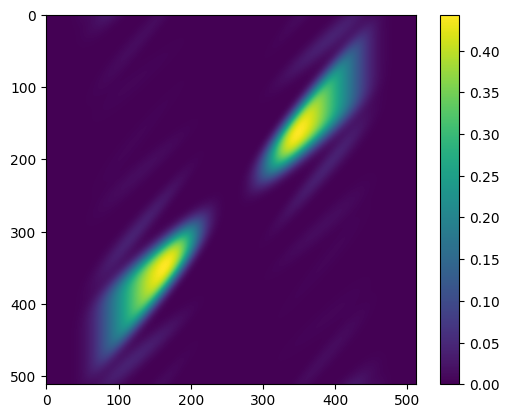

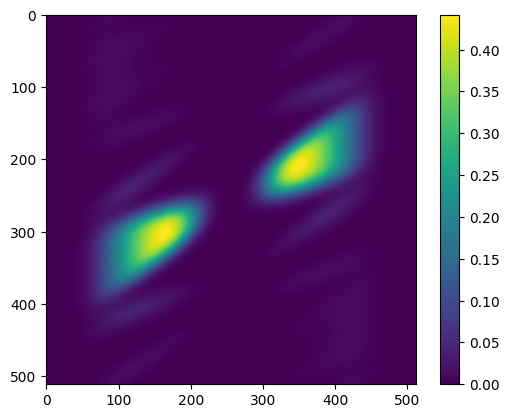

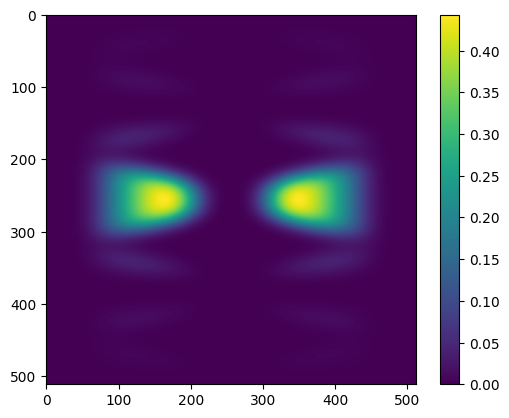

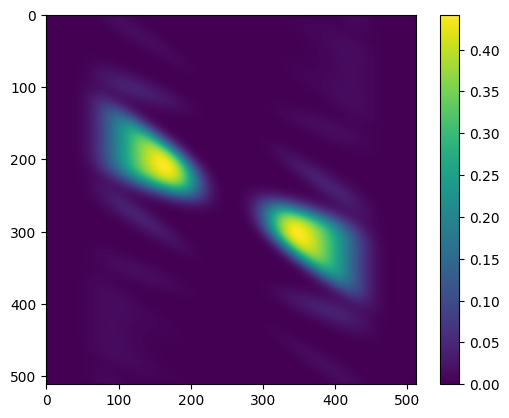

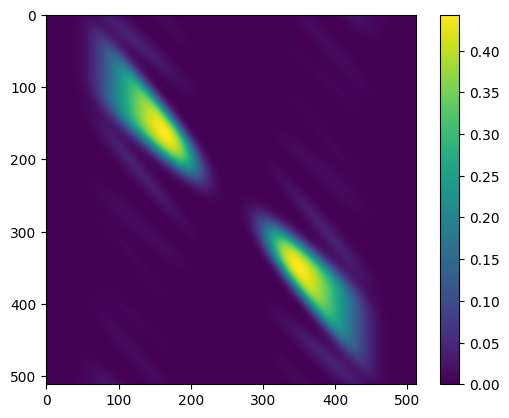

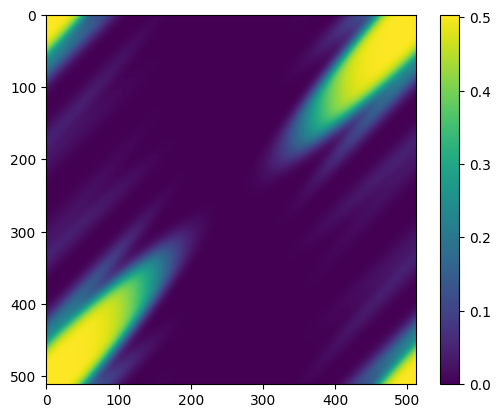

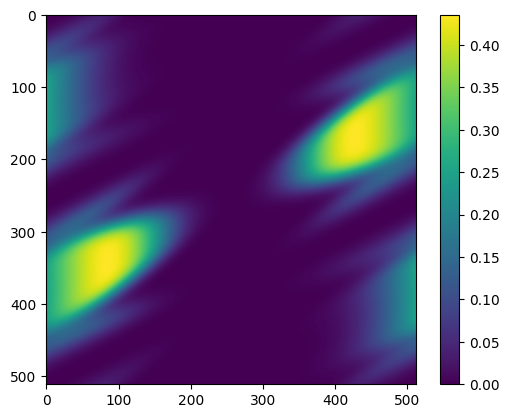

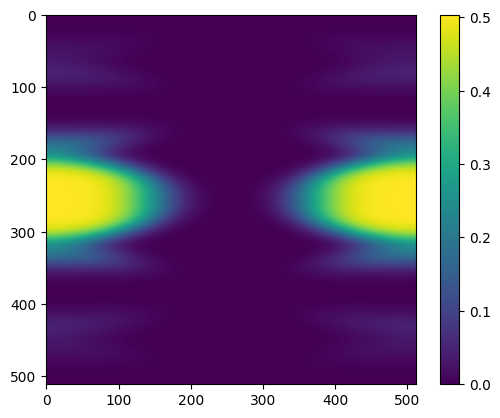

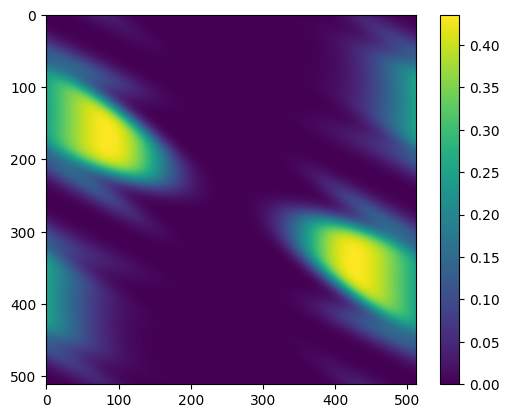

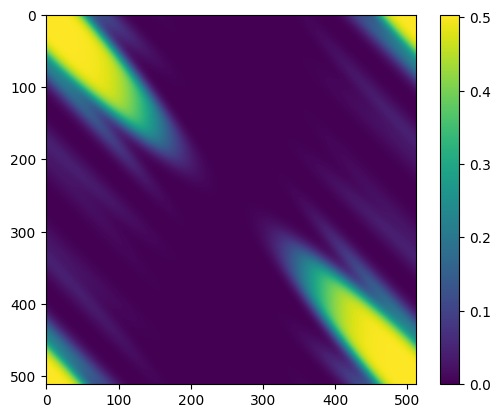

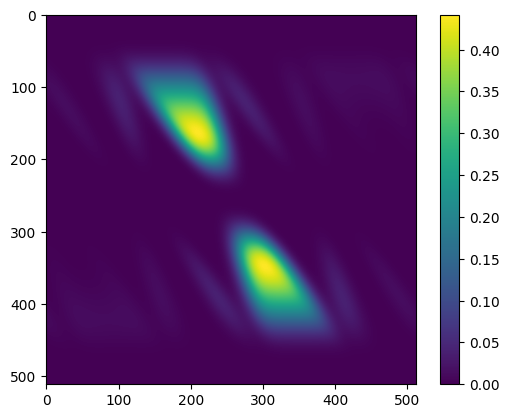

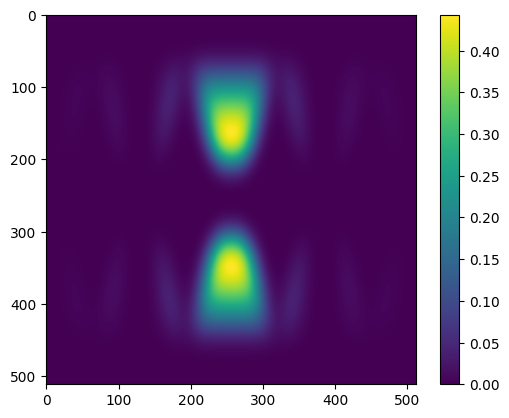

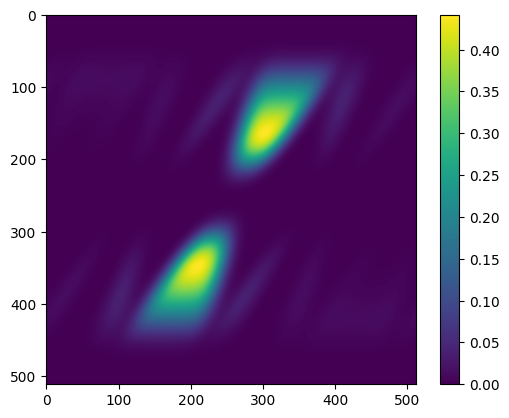

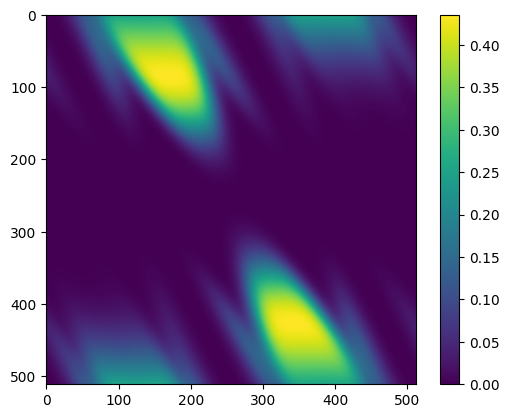

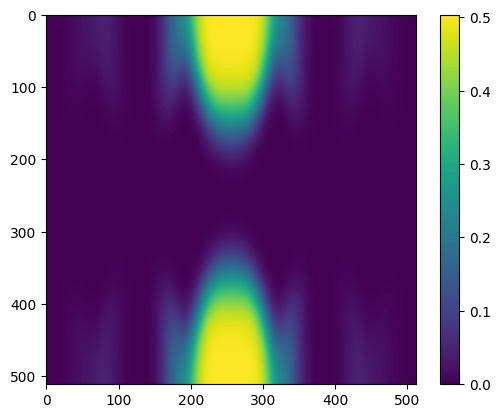

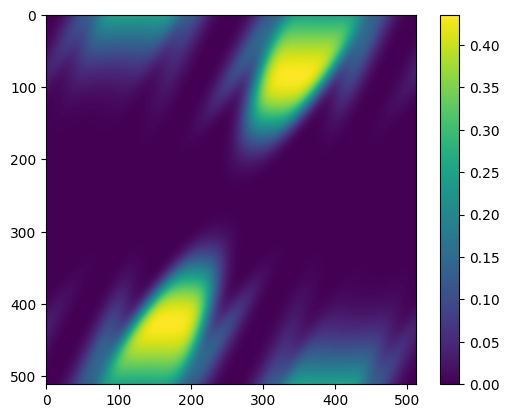

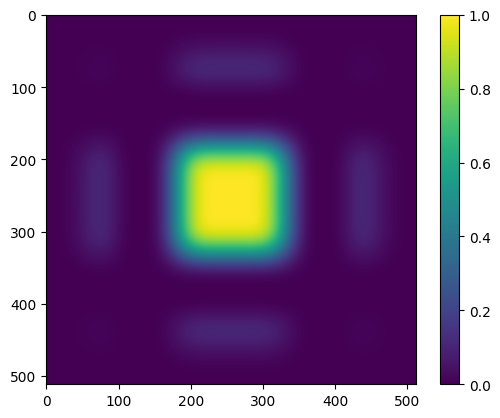

In [23]:
shearlets = shearletSystem["shearlets"]
print(shearlets.shape)

for i in range(shearlets.shape[-1]):
    sh = shearlets[:, :, i]
    # print(sh.shape)
    plt.imshow(sh.real)
    plt.colorbar()
    plt.show()

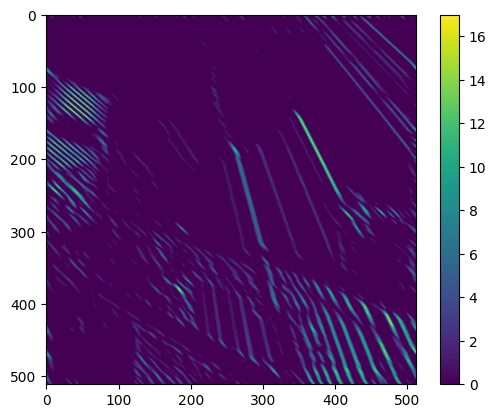

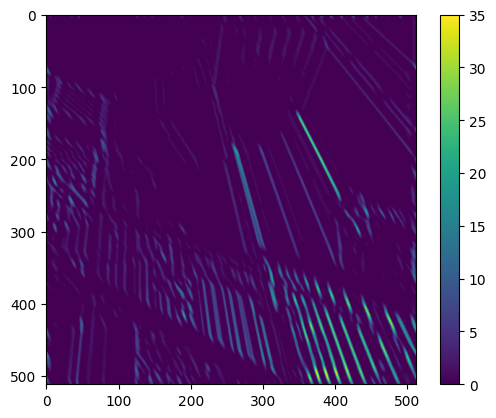

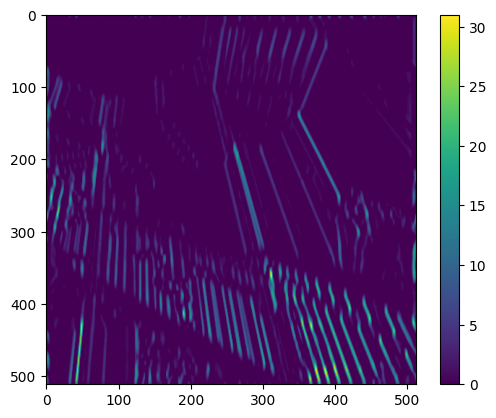

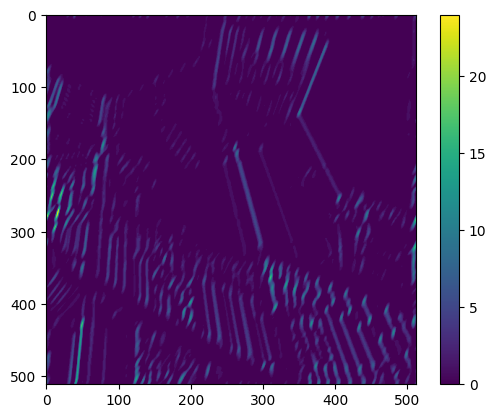

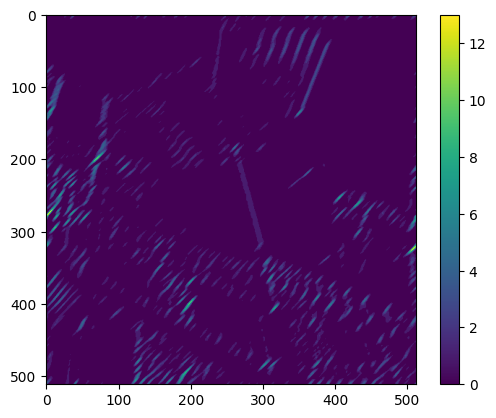

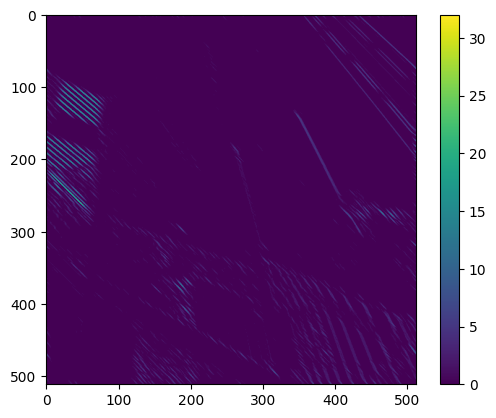

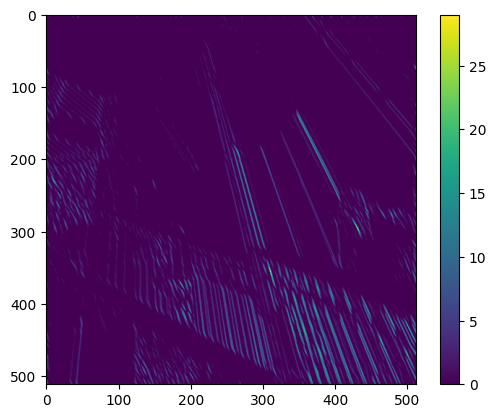

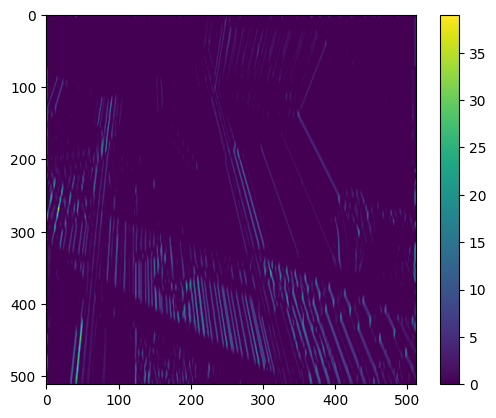

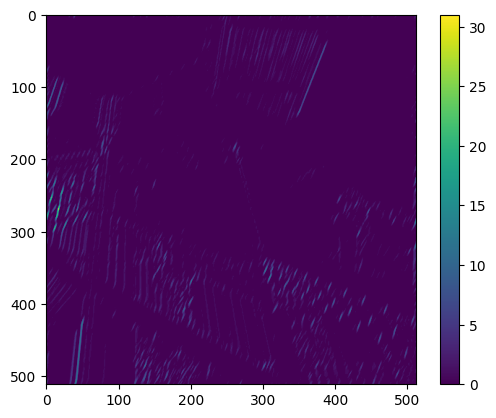

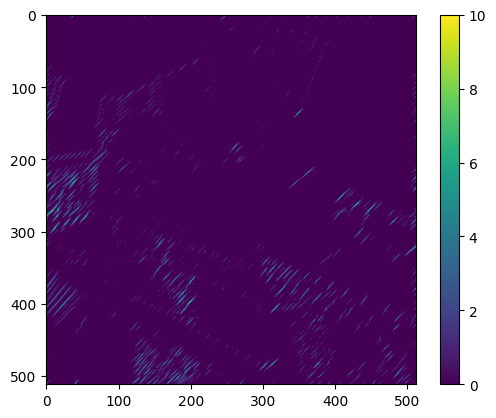

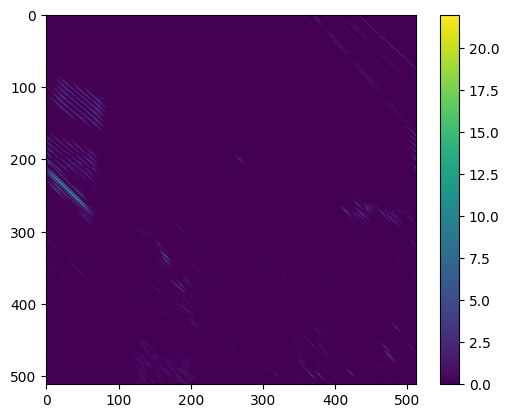

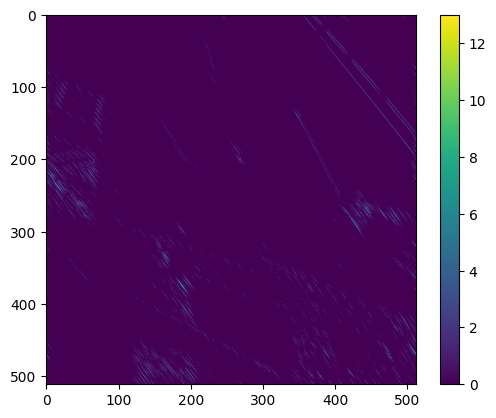

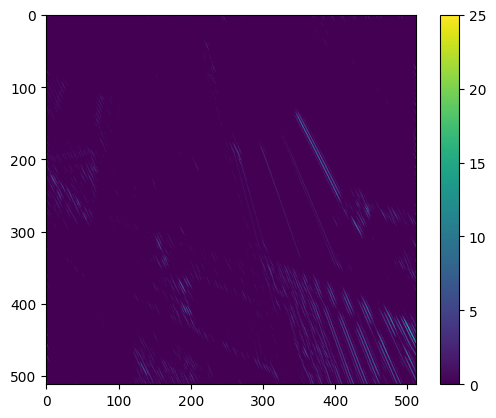

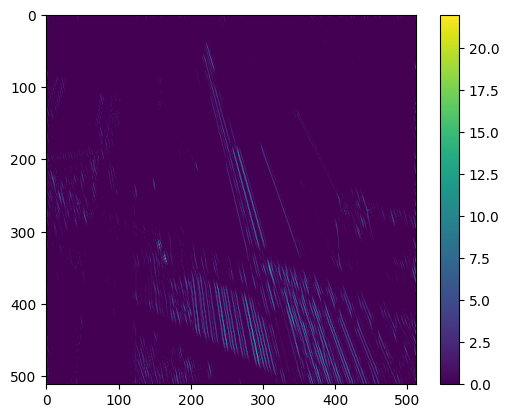

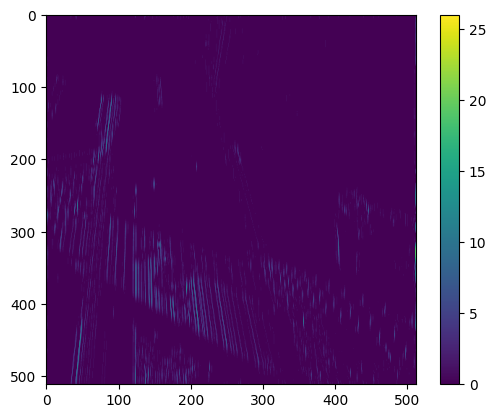

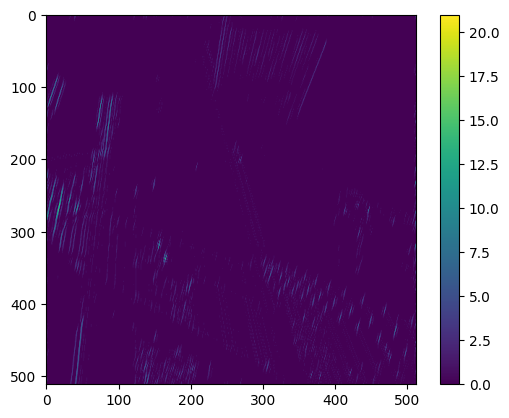

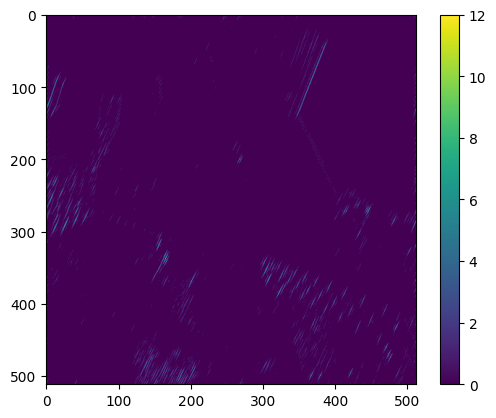

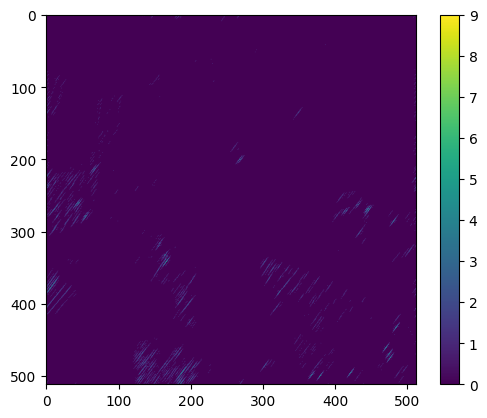

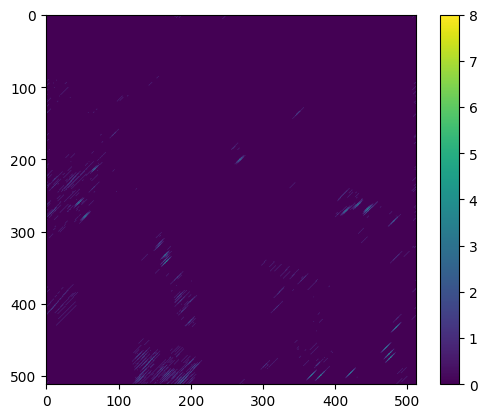

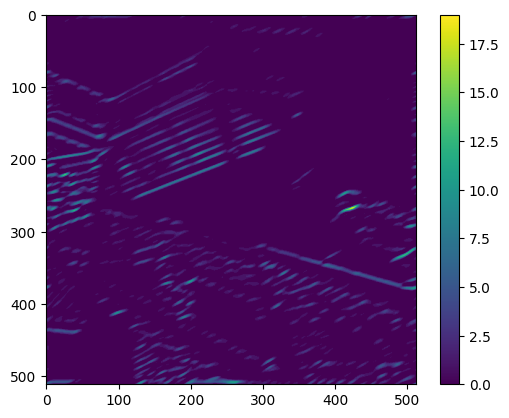

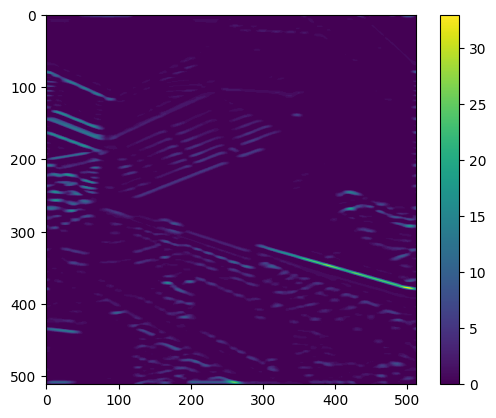

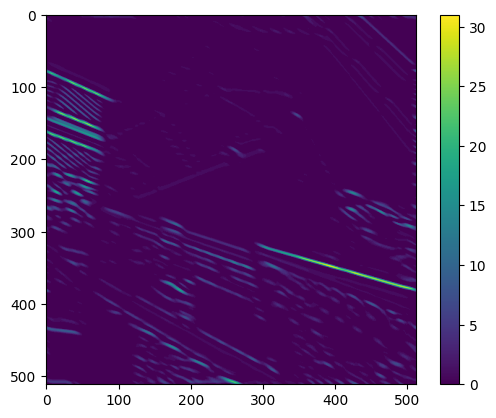

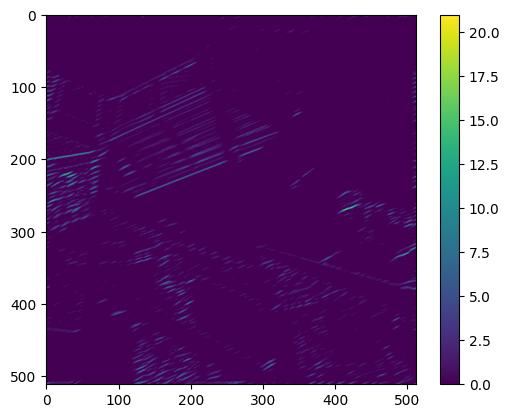

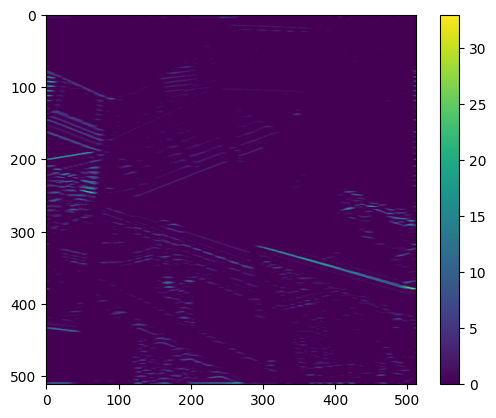

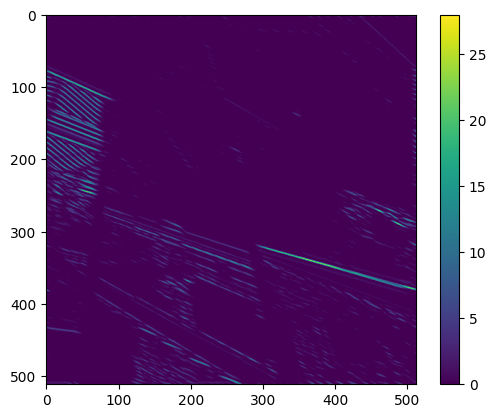

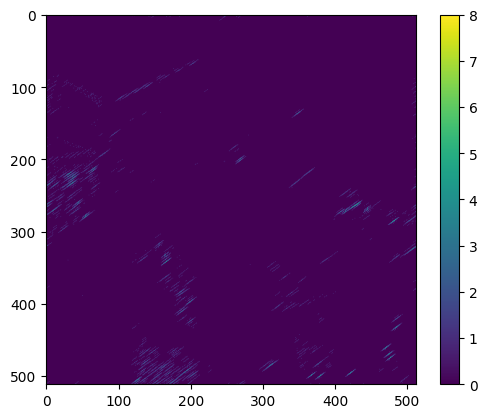

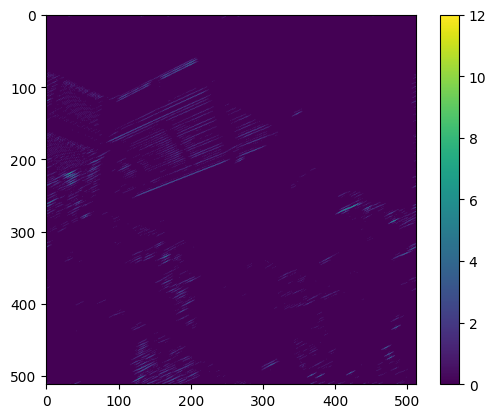

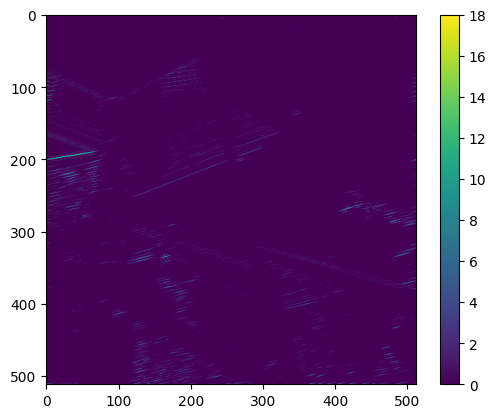

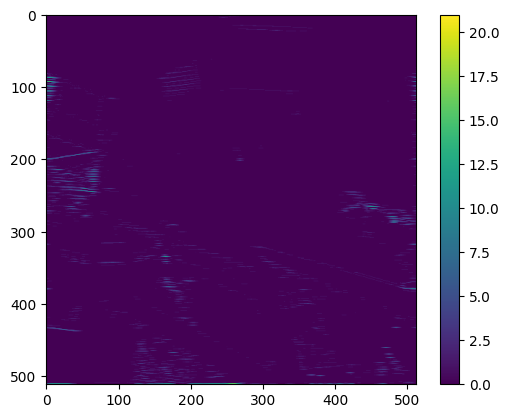

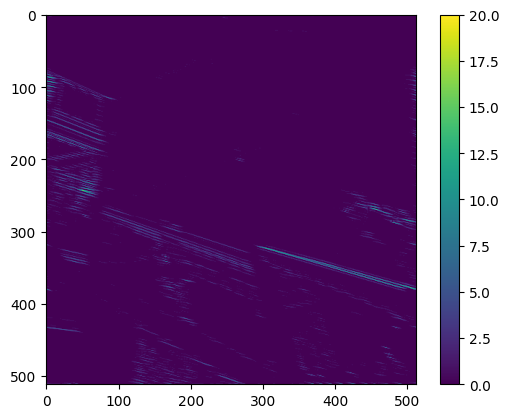

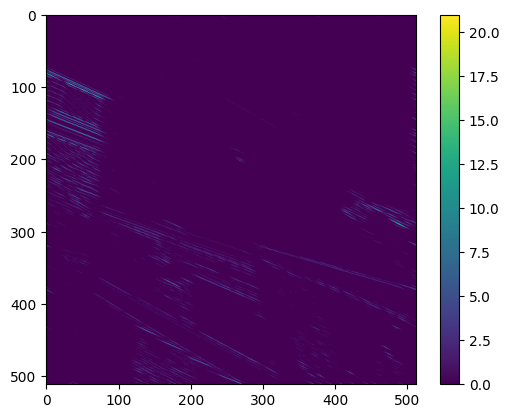

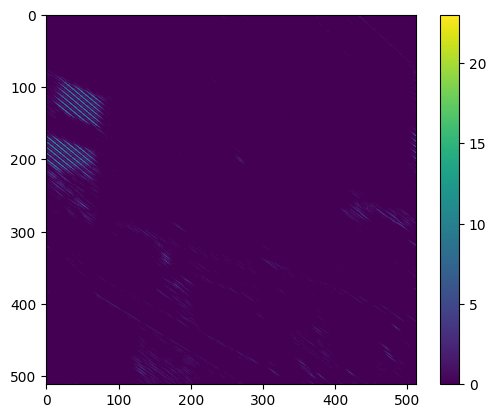

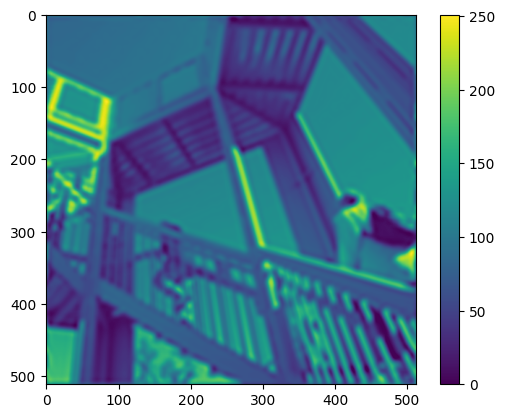

In [9]:
for index, sh in enumerate(shearlets.transpose(2, 0, 1)):
    v = np.nanmax(np.abs(sh))
    plt.imshow(sh, cmap="viridis")  # , vmin=-v, vmax=v)
    plt.colorbar()
    plt.show()

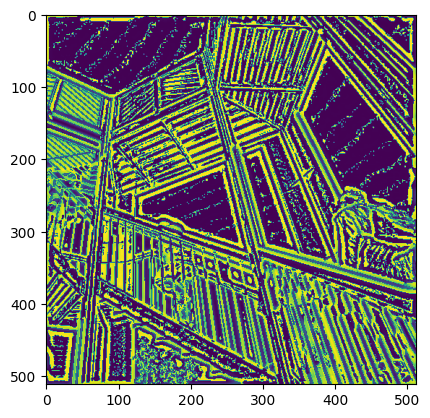

In [5]:
plt.imshow(ascent() - shearlets[:, :, -1])